# **How Economic Stress Shapes Musical Taste in the United States**

---



Students: Hoang Dieu Linh Nguyen, Tri Huynh

Project Pages:

[Project Website](https://evelynnguyenh.github.io)

[Project Repository Page](https://github.com/evelynnguyenh/evelynnguyenh.github.io)

### **About This Project**

Our project, “How Economic Stress Shapes Musical Taste in the United States,” analyzes periods of economic hardship alongside the musical responses of listeners, focusing on changes in genre, lyrical themes, and emotional tone. In this context, music serves not only as a form of artistic expression, but also as a reflection of a nation's social mood and cultural environment. Through this analysis, we aim to better understand how broader economic conditions may influence musical trends in the United States. Specifically, the project examines whether economic stress is associated with a shift toward more melancholic music or whether listeners prefer more energetic and optimistic songs as a form of escapism during difficult economic periods.






### **Project Datasets**
The datasets we are considering are the Billboard Hot 100 chart history, the Spotify Tracks Dataset 1921-2020, and the GDP-Based Recession Indicator from the Federal Reserve Bank of St. Louis (FRED).

We are interested in these datasets because they allow us to examine a question at the intersection of economics and music culture: does economic downturn change what music Americans listen to?

The Billboard Hot 100, published weekly since 1958, records which songs were most popular in the United States at any given time. The Spotify Tracks Dataset provides audio features including valence, energy, and danceability for over 600,000 real tracks sourced from Spotify's API. The FRED recession indicator marks which quarters were classified as recessions based on GDP data, serving as our economic anchor.

By combining these three datasets, we aim to answer our central question: do Americans gravitate toward sadder, lower-energy music during economic downturns? We can also explore whether certain audio features shift more than others, and whether any effect is immediate or lagged.




### **Collaboration Plan**
The team plans to meet in-person twice a week to review progress and align on next steps. Our primary communication channel is text messaging for quick updates between meetings. Work is divided equally and tracked through a shared Google Sheets task list with assigned to-do items. All project files are stored in a shared GitHub repository, which also hosts our GitHub Pages site, and a shared Google Drive folder for any additional resources. The notebook is maintained in Google Colab, with us coordinating over text before editing to avoid conflicts.

### **ETL (Extraction, Transform, and Load)**

First, we will load in the libraries we'll be using for this tutorial.

In [1]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

#### Loading the Datasets

We load all three datasets directly from our GitHub repository using their raw URLs, making the notebook reproducible for anyone without needing local file access.

In [2]:
# Load the datasets
songs = pd.read_csv('https://media.githubusercontent.com/media/evelynnguyenh/evelynnguyenh.github.io/refs/heads/main/songs.csv')
fed_recession = pd.read_csv('https://raw.githubusercontent.com/evelynnguyenh/evelynnguyenh.github.io/refs/heads/main/recession_data.csv')
billboard = pd.read_csv('https://raw.githubusercontent.com/evelynnguyenh/evelynnguyenh.github.io/refs/heads/main/charts.csv')

#### Billboard Top 100

Let's look at this dataset and examine its structure.

In [3]:
print("Shape:", billboard.shape, "\n")
print("Column names and dtypes:", billboard.dtypes, "\n")
print("Null counts per column:")
print(billboard.isnull().sum())
billboard.head(10)

Shape: (330087, 7) 

Column names and dtypes: date               object
rank                int64
song               object
artist             object
last-week         float64
peak-rank           int64
weeks-on-board      int64
dtype: object 

Null counts per column:
date                  0
rank                  0
song                  0
artist                0
last-week         32312
peak-rank             0
weeks-on-board        0
dtype: int64


,date,rank,song,artist,last-week,peak-rank,weeks-on-board
0,2021-11-06,1,Easy On Me,Adele,1.0,1,3
1,2021-11-06,2,Stay,The Kid LAROI & Justin Bieber,2.0,1,16
2,2021-11-06,3,Industry Baby,Lil Nas X & Jack Harlow,3.0,1,14
3,2021-11-06,4,Fancy Like,Walker Hayes,4.0,3,19
4,2021-11-06,5,Bad Habits,Ed Sheeran,5.0,2,18
5,2021-11-06,6,Way 2 Sexy,Drake Featuring Future & Young Thug,6.0,1,8
6,2021-11-06,7,Shivers,Ed Sheeran,9.0,7,7
7,2021-11-06,8,Good 4 U,Olivia Rodrigo,7.0,1,24
8,2021-11-06,9,Need To Know,Doja Cat,11.0,9,20
9,2021-11-06,10,Levitating,Dua Lipa,8.0,2,56


We can make some observations about this dataset:
- Each row represents a single song's appearance on the Billboard Hot 100 for a specific week, giving us 330,087 weekly chart entries in total.
- The `date` column is stored as a string object rather than a datetime64 dtype, which we will need to convert to the correct dtype.
- The `last-week` column contains 32,312 NaN values. This indicates that those songs were not on the chart the previous week, meaning it is a new entry.
- As a result of those NaNs, `last-week` is stored as float64 (e.g. 1.0, 2.0) instead of an integer.
- Column names use hyphens (`last-week`, `peak-rank`, `weeks-on-board`), which can cause errors so we will rename them to use underscores.
- The dataset is already tidy with one row per observation, one column per variable, so no restructuring is needed.

Convert the dtype of `date`

In [4]:
# Convert date from string to datetime
billboard['date'] = pd.to_datetime(billboard['date'])

# Verify that it worked
print(billboard['date'].dtype)
billboard['date'].head()

datetime64[ns]


,date
0,2021-11-06
1,2021-11-06
2,2021-11-06
3,2021-11-06
4,2021-11-06


Now let's rename columns to use an underscore instead of hyphen. Then, we convert the dtype from float64 to Int64 since rank values should be whole numbers, and Int64 also supports NaN values. We want to keep NaN here because it's a meaningful value which indicates a song's first appearance on the chart.

In [5]:
# Rename hyphen to underscore
billboard = billboard.rename(columns={
    'last-week': 'last_week',
    'peak-rank': 'peak_rank',
    'weeks-on-board': 'weeks_on_board'
})

# Convert last_week from float64 to nullable integer
# Int64 (capital I) supports NaN, regular int64 does not
billboard['last_week'] = billboard['last_week'].astype('Int64')

# Verify
print(billboard.dtypes)
print()
print("NaN count in last_week:", billboard['last_week'].isna().sum())

date              datetime64[ns]
rank                       int64
song                      object
artist                    object
last_week                  Int64
peak_rank                  int64
weeks_on_board             int64
dtype: object

NaN count in last_week: 32312


## **EDA (Exploratory Data Analysis)**

Let's examine how long songs typically remain on the Billboard chart

In [6]:
billboard['weeks_on_board'].mean()

np.float64(9.161784620418253)

Let's get a more general overview of our dataset

In [7]:
billboard['weeks_on_board'].describe()

,weeks_on_board
count,330087.000000
mean,9.161785
std,7.618264
min,1.000000
25%,4.000000
50%,7.000000
75%,13.000000
max,90.000000


Looking at this, we can deduce that half of the songs stay on the billboard for over 7 weeks.

Examining the artists who appear most frequently in the dataset helps identify musicians who consistently produce charting songs

In [8]:
billboard['artist'].value_counts().head(10)

,count
artist,
Taylor Swift,1023
Elton John,889
Madonna,857
Drake,787
Kenny Chesney,769
Tim McGraw,731
Keith Urban,673
Stevie Wonder,659
Rod Stewart,657


We plot the distribution of weeks that songs stay on the Billboard Hot 100 chart to understand how long songs typically remain popular.

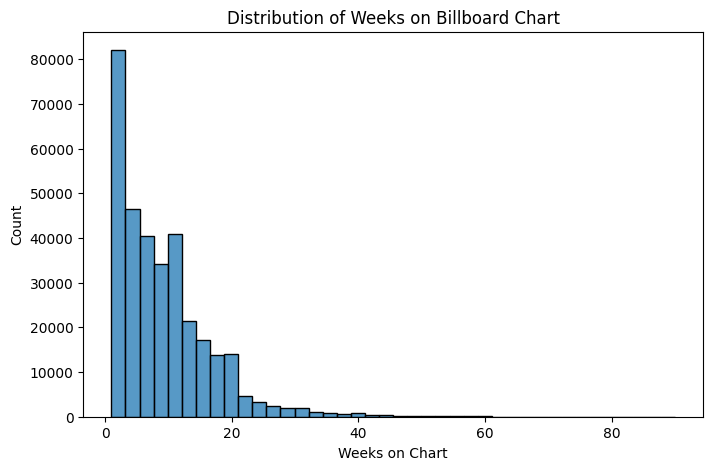

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(billboard['weeks_on_board'], bins=40)
plt.title("Distribution of Weeks on Billboard Chart")
plt.xlabel("Weeks on Chart")
plt.ylabel("Count")
plt.show()

This distribution shows that most songs remain on the chart for fewer than 15 weeks, while only a small number of songs stay for much longer periods

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
%%shell
jupyter nbconvert --to html "/content/drive/MyDrive/CMPS3160 Project/cmps3160.ipynb"

[NbConvertApp] Converting notebook /content/drive/MyDrive/CMPS3160 Project/cmps3160.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 347373 bytes to /content/drive/MyDrive/CMPS3160 Project/cmps3160.html
